# Data Preprocessing Tutorial

This notebook demonstrates various data preprocessing techniques using the Penguins dataset. We'll cover:
- Missing value imputation
- Feature encoding (Label Encoding, One-Hot Encoding)
- Feature scaling (Standardization)
- Building preprocessing pipelines

In [1]:
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import seaborn as sns

## Step 1: Import Required Libraries

- **pandas**: Data manipulation and analysis
- **numpy**: Numerical operations
- **sklearn.preprocessing**: Tools for data transformation (scaling, encoding)
- **sklearn.impute**: For handling missing values
- **seaborn**: Data visualization and dataset loading

In [2]:
penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Step 2: Load Data

Load the penguin dataset. This dataset contains measurements of different penguin species with both numeric and categorical features.

In [3]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Step 3: Check for Missing Values

Missing data can cause problems in machine learning models. We check which columns have missing values and how many.

In [4]:
num_cols = penguins.select_dtypes('number').columns
print(num_cols.tolist())

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


## Step 4: Separate Numeric and Categorical Columns

Different columns require different preprocessing approaches:
- **Numeric columns**: Need scaling/standardization
- **Categorical columns**: Need encoding to convert to numeric format

In [5]:
cat_cols = penguins.select_dtypes(exclude='number').columns
print(cat_cols.tolist())

['species', 'island', 'sex']


In [6]:
num_imp = SimpleImputer()
cat_imp = SimpleImputer(strategy='most_frequent')

## Step 5: Handle Missing Values with Imputation

**SimpleImputer** strategies:
- **Numeric columns**: Fill missing values with mean (default)
- **Categorical columns**: Fill missing values with most frequent category

In [7]:
penguins[num_cols] = num_imp.fit_transform(penguins[num_cols])
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,NaN
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,Female


In [8]:
penguins[['sex']] = cat_imp.fit_transform(penguins[['sex']])
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,Male
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,Female


In [9]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.443643,1.969027,14.020657,799.613058
min,32.100000,13.100000,172.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.250000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [10]:
sex_enc = LabelEncoder()
penguins['sex'] = sex_enc.fit_transform(penguins['sex'])

In [12]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,1
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,0
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,0
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,1
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,0
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,1
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,0
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,1
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,0


In [11]:
penguins.iloc[153]

species              Chinstrap
island                   Dream
bill_length_mm            50.0
bill_depth_mm             19.5
flipper_length_mm        196.0
body_mass_g             3900.0
sex                          1
Name: 153, dtype: object

## Step 6: Encode Categorical Variables

### Label Encoding
Converts categorical values into numeric labels (e.g., Male → 1, Female → 0).
**Use case**: Binary categorical features or ordinal data where order matters.
Here we encode the 'sex' column.

In [13]:
print(penguins['sex'])

0      1
1      0
2      0
3      1
4      0
      ..
339    1
340    0
341    1
342    0
343    1
Name: sex, Length: 344, dtype: int64


In [14]:
cat_enc = OneHotEncoder(drop='first')
dummy_cols = cat_enc.fit_transform(penguins[cat_cols]).toarray()
dummy_df = pd.DataFrame(dummy_cols)

### One-Hot Encoding
Creates binary columns for each category. For example, if 'island' has values [Torgersen, Biscoe, Dream], it creates 3 binary columns.
**Use case**: Nominal categorical features (no inherent order). The `drop='first'` prevents multicollinearity.
Here we encode island and species columns.

In [15]:
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [16]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [30]:
dummy_df

,0,1,2,3,4
0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,1.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
339,0.0,1.0,0.0,0.0,1.0
340,0.0,1.0,0.0,0.0,0.0
341,0.0,1.0,0.0,0.0,1.0
342,0.0,1.0,0.0,0.0,0.0


In [17]:
scaler = StandardScaler()
penguins[num_cols] = scaler.fit_transform(penguins[num_cols])
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,-8.870812e-01,7.877425e-01,-1.422488,-0.565789,1
1,Adelie,Torgersen,-8.134940e-01,1.265563e-01,-1.065352,-0.503168,0
2,Adelie,Torgersen,-6.663195e-01,4.317192e-01,-0.422507,-1.192003,0
3,Adelie,Torgersen,-1.307172e-15,1.806927e-15,0.000000,0.000000,1
4,Adelie,Torgersen,-1.328605e+00,1.092905e+00,-0.565361,-0.941517,0
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,-1.307172e-15,1.806927e-15,0.000000,0.000000,1
340,Gentoo,Biscoe,5.294731e-01,-1.450118e+00,1.006038,0.811880,0
341,Gentoo,Biscoe,1.191758e+00,-7.380718e-01,1.506028,1.939064,1
342,Gentoo,Biscoe,2.351241e-01,-1.195816e+00,0.791756,1.250229,0


## Step 7: Feature Scaling with StandardScaler

**StandardScaler** (Standardization):
- Transforms features to have mean = 0 and standard deviation = 1
- Formula: (X - mean) / std_dev
- **Why**: Many algorithms (KNN, SVM, Neural Networks) perform better with scaled features
- **Benefit**: Ensures all features contribute equally to the model

## Step 8: Building a Complete Preprocessing Pipeline

A **Pipeline** chains multiple preprocessing steps into a single object, ensuring:
- Steps are applied in the correct order
- No data leakage (fit on training data only)
- Easy to apply the same transformations to new data
- Cleaner, more maintainable code

**ColumnTransformer** applies different pipelines to different column types simultaneously.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df = sns.load_dataset('penguins')
num_cols = df.select_dtypes('number').columns
cat_cols = df.select_dtypes(exclude='number').columns

num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps = (
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first'))
    )
)

In [20]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [21]:
data = preprocessor.fit_transform(df)

In [22]:
dff =  pd.DataFrame(data, columns=num_cols.tolist() + preprocessor.transformers_[1][1]['encoder'].get_feature_names_out(cat_cols).tolist())
dff

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,-8.870812e-01,7.877425e-01,-1.422488,-0.565789,0.0,0.0,0.0,1.0,1.0
1,-8.134940e-01,1.265563e-01,-1.065352,-0.503168,0.0,0.0,0.0,1.0,0.0
2,-6.663195e-01,4.317192e-01,-0.422507,-1.192003,0.0,0.0,0.0,1.0,0.0
3,-1.307172e-15,1.806927e-15,0.000000,0.000000,0.0,0.0,0.0,1.0,1.0
4,-1.328605e+00,1.092905e+00,-0.565361,-0.941517,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
339,-1.307172e-15,1.806927e-15,0.000000,0.000000,0.0,1.0,0.0,0.0,1.0
340,5.294731e-01,-1.450118e+00,1.006038,0.811880,0.0,1.0,0.0,0.0,0.0
341,1.191758e+00,-7.380718e-01,1.506028,1.939064,0.0,1.0,0.0,0.0,1.0
342,2.351241e-01,-1.195816e+00,0.791756,1.250229,0.0,1.0,0.0,0.0,0.0


# Advanced Preprocessing: Iris Dataset

Now let's apply preprocessing techniques to a different dataset with additional methods.

## Easy English: Special Preprocessing Terms

- **Preprocessing**: Cleaning and preparing raw data before training a machine learning model.
- **Missing Value**: A data point that is empty or not available.
- **SimpleImputer**: A tool that fills missing values.
  - For numbers, it can fill with average (mean) or median.
  - For categories, it can fill with the most common value.
- **Outlier**: A value that is very different from most other values (too high or too low).
- **Outlier Detection**: The process of finding unusual values in data.
- **IQR (Interquartile Range)**: A measure of spread in the middle part of data.
  - $IQR = Q3 - Q1$
  - It helps find outliers.
- **IQR Method for Outliers**: A common rule to detect outliers.
  - Lower limit: $Q1 - 1.5 \times IQR$
  - Upper limit: $Q3 + 1.5 \times IQR$
  - Values outside these limits are treated as outliers.
- **Label Encoding**: Converting text labels into numbers.
  - Example: `Male -> 1`, `Female -> 0`
- **One-Hot Encoding**: Creating separate 0/1 columns for each category.
  - Example: `Red, Blue, Green` becomes 3 columns.
- **StandardScaler (Standardization)**: Changes numeric values so features have similar scale.
  - It usually makes mean around 0 and standard deviation around 1.
- **MinMaxScaler (Normalization)**: Rescales numeric values to a fixed range, usually $[0,1]$.
- **Feature Scaling**: Changing feature ranges so no feature dominates because of large numbers.
- **Train-Test Split**: Dividing data into two parts.
  - Train set: used to learn.
  - Test set: used to check performance on unseen data.
- **Correlation**: Shows how strongly two features move together.
- **SelectKBest**: Automatically picks the top `k` most useful features.
- **Pipeline**: A step-by-step chain of preprocessing operations run in order.
- **ColumnTransformer**: Applies different preprocessing steps to different column groups (numeric vs categorical).

In [42]:
## Load Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

print("Dataset Shape:", iris_df.shape)
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nData Info:")
print(iris_df.info())

Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target          

In [43]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## Load and Explore Dataset

Load the Iris dataset and examine its structure, statistics, and missing values.

In [44]:
## Check Basic Statistics
print("Statistical Summary:")
print(iris_df.describe())
print("\nMissing Values:")
print(iris_df.isnull().sum())
print("\nTarget Distribution:")
print(iris_df['target'].value_counts().sort_index())

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values:
sepal length (cm)    0
sepal width

## Outlier Detection using IQR (Interquartile Range)

**IQR Method**:
- IQR = Q3 - Q1 (75th percentile - 25th percentile)
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Values outside these bounds are outliers

**Why it matters**: Outliers can skew model performance and statistics. We can remove or handle them specially.

In [45]:
iris_copy = iris_df.copy()
feature_columns = iris_copy.columns[:-1]  # Exclude target column

# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

outlier_mask = pd.DataFrame(False, index=iris_copy.index, columns=feature_columns)
for col in feature_columns:
    outlier_mask[col] = detect_outliers_iqr(iris_copy, col)

print("Outliers detected:")
print(outlier_mask.sum())
print(f"\nTotal rows with outliers: {outlier_mask.any(axis=1).sum()}")

# Remove outliers
iris_clean = iris_copy[~outlier_mask.any(axis=1)]
print(f"Rows before: {len(iris_copy)}, Rows after: {len(iris_clean)}")

Outliers detected:
sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64

Total rows with outliers: 4
Rows before: 150, Rows after: 146


## Feature Normalization using MinMaxScaler

**MinMaxScaler** (Normalization):
- Scales features to a fixed range [0, 1]
- Formula: (X - min) / (max - min)
- **When to use**: When you need values in a specific range (e.g., neural networks, image processing)
- **Difference from StandardScaler**: Values are bounded, preserves zeros

In [46]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
iris_normalized = iris_clean.copy()
iris_normalized[feature_columns] = minmax_scaler.fit_transform(iris_clean[feature_columns])

print("Before Normalization (first 5 rows):")
print(iris_clean[feature_columns].head())
print("\nAfter Normalization (first 5 rows):")
print(iris_normalized[feature_columns].head())
print("\nMin and Max values after scaling:")
print(f"Min: {iris_normalized[feature_columns].min().min()}")
print(f"Max: {iris_normalized[feature_columns].max().max()}")

Before Normalization (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

After Normalization (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.722222           0.067797          0.041667
1           0.166667          0.444444           0.067797          0.041667
2           0.111111          0.555556           0.050847          0.041667
3           0.083333          0.500000           0.084746          0.041667
4           0.194444          0.777778           0.067797          0.041667

Min and Max v

## Train-Test Split

**Why split data?**
- Train set: Used to fit the model
- Test set: Used to evaluate generalization performance
- Prevents overfitting by evaluating on unseen data
- Typical split: 70-30 or 80-20

In [47]:
X = iris_normalized[feature_columns]  # Features
y = iris_normalized['target']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFeature shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

Training set size: 116 samples
Test set size: 30 samples

Feature shape: (116, 4)
Target shape: (116,)

Class distribution in training set:
target
0    37
1    39
2    40
Name: count, dtype: int64


## Feature Correlation Analysis

**Why check correlations?**
- Identify redundant features (highly correlated features provide similar information)
- Understand feature relationships
- Remove multicollinear features to improve model interpretability
- Features with correlation > 0.9 or < -0.9 are often candidates for removal

Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.123144           0.879362   
sepal width (cm)           -0.123144          1.000000          -0.406141   
petal length (cm)           0.879362         -0.406141           1.000000   
petal width (cm)            0.822587         -0.340602           0.961866   

                   petal width (cm)  
sepal length (cm)          0.822587  
sepal width (cm)          -0.340602  
petal length (cm)          0.961866  
petal width (cm)           1.000000  


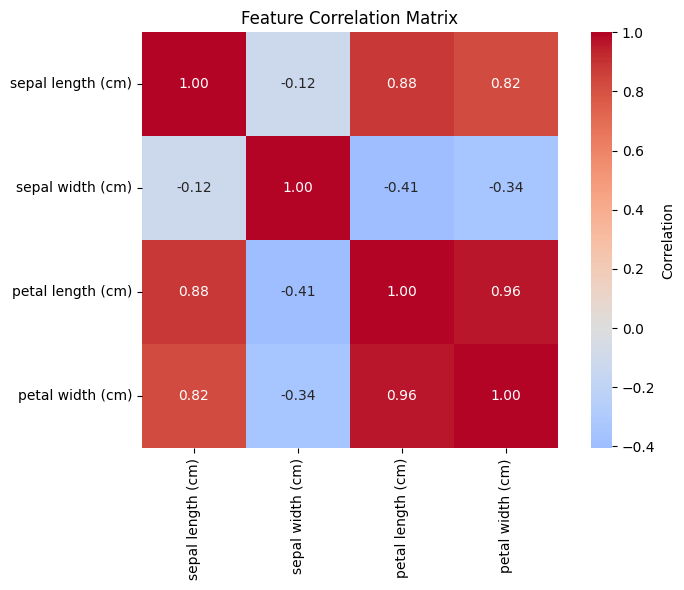


Highly Correlated Feature Pairs (|correlation| > 0.8):
sepal length (cm) <-> petal length (cm): 0.879
sepal length (cm) <-> petal width (cm): 0.823
petal length (cm) <-> petal width (cm): 0.962


In [48]:
from matplotlib import pyplot as plt
# Calculate correlation matrix
correlation_matrix = iris_normalized[feature_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Find highly correlated features
print("\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

## Feature Selection using SelectKBest

**SelectKBest** selects the K best features based on statistical tests.

**Methods:**
- **f_classif**: For classification (ANOVA F-test)
- **mutual_info_classif**: Mutual information between features and target
- **f_regression**: For regression (correlation)

**Why feature selection?**
- Reduces model complexity
- Improves training speed
- Reduces overfitting risk
- Improves interpretability

In [49]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 3 features
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_train, y_train)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': feature_columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Feature Importance Scores:")
print(feature_scores)

# Get selected features
selected_features = feature_scores.head(3)['Feature'].tolist()
print(f"\nTop 3 Selected Features: {selected_features}")

# Create new dataset with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

Feature Importance Scores:
             Feature       Score
2  petal length (cm)  863.989481
3   petal width (cm)  799.674210
0  sepal length (cm)   95.242572
1   sepal width (cm)   43.177032

Top 3 Selected Features: ['petal length (cm)', 'petal width (cm)', 'sepal length (cm)']

Original features: 4
Selected features: 3


## Complete Preprocessing Pipeline Summary

A typical machine learning preprocessing workflow includes:

1. **Data Loading & Exploration**: Understand data structure, size, and types
2. **Missing Value Handling**: Impute or remove missing data
3. **Outlier Detection**: Identify and handle extreme values (IQR method)
4. **Feature Encoding**: Convert categorical to numeric (Label/One-Hot encoding)
5. **Feature Scaling**: Normalize/Standardize features (MinMaxScaler/StandardScaler)
6. **Feature Selection**: Choose most relevant features (SelectKBest)
7. **Train-Test Split**: Separate data for training and evaluation
8. **Correlation Analysis**: Check for multicollinearity

**Pipeline Implementation with Scikit-Learn:**

In [50]:
# Complete preprocessing pipeline for Iris dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

# Create a complete pipeline
complete_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),  # Scale features
        ('feature_selection', SelectKBest(f_classif, k=3))  # Select top 3 features
    ]
)

# Fresh data
iris_fresh = load_iris()
X_fresh = pd.DataFrame(iris_fresh.data, columns=iris_fresh.feature_names)
y_fresh = iris_fresh.target

# Split data
X_train_fresh, X_test_fresh, y_train_fresh, y_test_fresh = train_test_split(
    X_fresh, y_fresh, test_size=0.2, random_state=42, stratify=y_fresh
)

# Fit and transform
X_train_processed = complete_pipeline.fit_transform(X_train_fresh, y_train_fresh)
X_test_processed = complete_pipeline.transform(X_test_fresh)

print("Pipeline Execution Results:")
print(f"Original training shape: {X_train_fresh.shape}")
print(f"Processed training shape: {X_train_processed.shape}")
print(f"Original test shape: {X_test_fresh.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

# Display pipeline steps
print("\nPipeline Steps:")
for name, step in complete_pipeline.named_steps.items():
    print(f"  - {name}: {type(step).__name__}")

Pipeline Execution Results:
Original training shape: (120, 4)
Processed training shape: (120, 3)
Original test shape: (30, 4)
Processed test shape: (30, 3)

Pipeline Steps:
  - scaler: StandardScaler
  - feature_selection: SelectKBest


In [51]:
complete_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...0023F246214E0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",3
